In [5]:
import sys
import os
import torch
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import pandas as pd
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.torch_lightning.lightning_data_module import DroneDataModule
from src.torch_lightning.lightning_module import DroneClassifier

pl.seed_everything(42)

Seed set to 42


42

In [6]:
N_MELS = 128

dm = DroneDataModule(
    root_dir="data",
    dataset_type="binary",
    batch_size=16,
    num_workers=0,
    n_mels=N_MELS
)

dm.prepare_data()
dm.setup()

num_classes = len(dm.class_to_idx)
print(f"Liczba wykrytych klas: {num_classes} ({dm.class_to_idx})")

[download_drone_audio.py] Downloading dataset from: https://codeload.github.com/saraalemadi/DroneAudioDataset/zip/refs/heads/master
[download_drone_audio.py] Saved zip to: data\DroneAudioDataset_master.zip
[download_drone_audio.py] Extracting zip to: data
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757
Liczba wykrytych klas: 2 ({'unknown': 0, 'yes_drone': 1})


In [7]:
model = DroneClassifier(
    num_classes=num_classes,
    n_mels=N_MELS,
    learning_rate=1e-4
)

In [8]:
checkpoint_callback = ModelCheckpoint(
    monitor="val_acc",
    dirpath="checkpoints",
    filename="drone-mamba-{epoch:02d}-{val_acc:.2f}",
    save_top_k=1,
    mode="max",
)

early_stop_callback = EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min"
)

logger = CSVLogger("logs", name="drone_detection_mamba")

In [9]:
trainer = pl.Trainer(
    max_epochs=30,
    accelerator="auto",
    devices=1,
    callbacks=[checkpoint_callback, early_stop_callback],
    logger=logger,
    log_every_n_steps=5
)

trainer.fit(model, datamodule=dm)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757



  | Name        | Type                      | Params | Mode 
------------------------------------------------------------------
0 | model       | DroneDetectorMamba        | 6.1 M  | train
1 | train_acc   | MulticlassAccuracy        | 0      | train
2 | val_acc     | MulticlassAccuracy        | 0      | train
3 | test_acc    | MulticlassAccuracy        | 0      | train
4 | test_f1     | MulticlassF1Score         | 0      | train
5 | conf_matrix | MulticlassConfusionMatrix | 0      | train
6 | loss_fn     | CrossEntropyLoss          | 0      | train
------------------------------------------------------------------
6.1 M     Trainable params
0         Non-trainable params
6.1 M     Total params
24.478    Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\jango\Anaconda\envs\segm-env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
c:\Users\jango\Anaconda\envs\segm-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


c:\Users\jango\Anaconda\envs\segm-env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Epoch 15: 100%|██████████| 512/512 [01:11<00:00,  7.20it/s, v_num=0, val_loss=0.0306, val_acc=0.984, train_loss=0.0688, train_acc=0.975]


In [10]:
trainer.test(model, datamodule=dm, ckpt_path="best")

Restoring states from the checkpoint path at C:\Users\jango\Desktop\IO\DroneAcusticDetection\checkpoints\drone-mamba-epoch=10-val_acc=0.99.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at C:\Users\jango\Desktop\IO\DroneAcusticDetection\checkpoints\drone-mamba-epoch=10-val_acc=0.99.ckpt
c:\Users\jango\Anaconda\envs\segm-env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757
Testing DataLoader 0: 100%|██████████| 110/110 [00:29<00:00,  3.78it/s]
Confusion Matrix:
tensor([[1560,    4],
        [  12,  181]], device='cuda:0')
Testing DataLoader 0: 100%|██████████| 110/110 [00:29<00:00,  3.77it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc             0.990893542766571
         test_f1             0.990893542766571
        test_loss           0.02551165781915188
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.02551165781915188,
  'test_acc': 0.990893542766571,
  'test_f1': 0.990893542766571}]

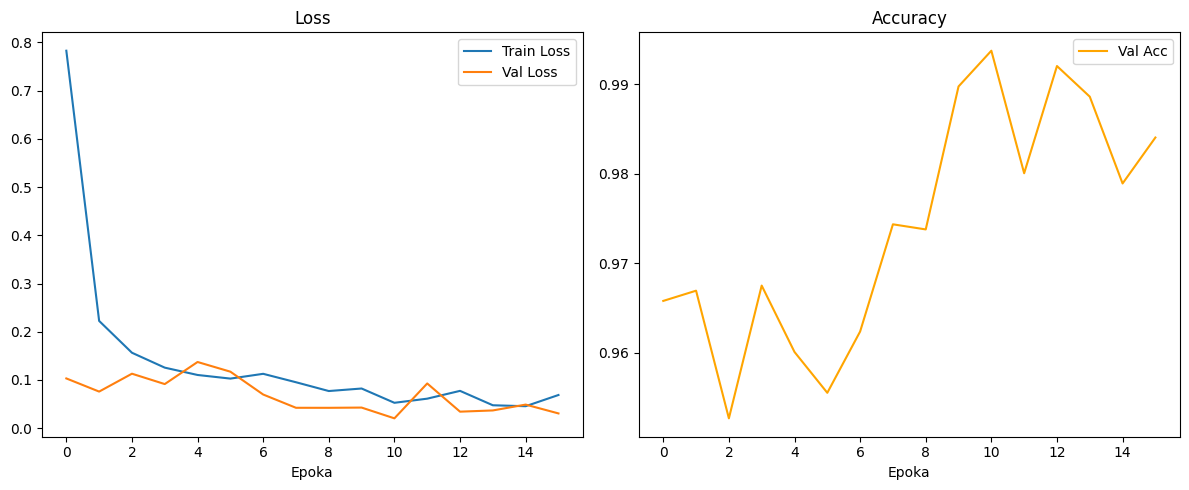

In [11]:
metrics_path = os.path.join(logger.log_dir, "metrics.csv")
if os.path.exists(metrics_path):
    metrics = pd.read_csv(metrics_path)
    
    train_loss = metrics.dropna(subset=['train_loss'])
    val_loss = metrics.dropna(subset=['val_loss'])

    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_loss['epoch'], train_loss['train_loss'], label='Train Loss')
    plt.plot(val_loss['epoch'], val_loss['val_loss'], label='Val Loss')
    plt.xlabel('Epoka')
    plt.title('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(val_loss['epoch'], val_loss['val_acc'], label='Val Acc', color='orange')
    plt.xlabel('Epoka')
    plt.title('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()